# NEOMOD3 density-estimator map comparison — mechanism diagnostic

Three complete map sets over all **667** centers, built by **one shared code path** parameterized
by `density_mode`, with all additional Gaussian smoothing disabled:

| mode | NEO | MBA / TNO / Trojans |
|---|---|---|
| `HIST_ALL` | weighted histogram | weighted histogram |
| `BAYES_ALL` | Bayesian kNN | Bayesian kNN |
| `BAYES_NONNEO` | weighted histogram | Bayesian kNN |

Everything else is held identical: source rows, weights, map membership, magnitude bins, velocity
grid, support handling, normalization, serialization and interpolation.

**Empty histogram pixels are UNDEFINED, not zero probability.** Where the four densities sum to
zero the posterior is NaN with a reason code; it is never rendered or tabulated as 0.

In [1]:
import glob, json, hashlib
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib; import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
plt.rcParams.update({"figure.dpi":110,"font.size":9,"axes.grid":False})
W = Path("/mmfs1/gscratch/dirac/ds2004/sorcha")
B = W/"outputs/geometric_density_estimator_ablation/full"
MODES = ["hist_all","bayes_all","bayes_nonneo"]
POPS  = ["NEO","MBA","TNO","Trojans"]
seal  = json.load(open(W/"outputs/splits/MAP_BUILD_SEAL.json"))
BINS  = [b[0] for b in seal["magnitude_bins"]]
EDG   = {b[0]:(float(b[1]),float(b[2])) for b in seal["magnitude_bins"]}
FEAT_CENTER, FEAT_BIN = "dlon+000_lat+00", "mag24+"   # GEN-densest NEO cell
print("maps per mode:", {m:len(list((B/f"maps_{m}").glob("prob_maps_grid_*.npz"))) for m in MODES})

maps per mode: {'hist_all': 667, 'bayes_all': 667, 'bayes_nonneo': 667}


## 1. Provenance and identity assertions

In [2]:
ident = json.load(open(W/"outputs/geometric_density_estimator_ablation/cross_mode_identity.json"))
mans = {m:{Path(f).name:json.load(open(f)) for f in sorted(glob.glob(str(B/f"maps_{m}"/"manifest_*.json")))}
        for m in MODES}
keys = sorted(mans["hist_all"])
assert all(len(mans[m])==667 for m in MODES)
for k in keys:
    ref = mans["hist_all"][k]["input_hashes"]
    for m in MODES[1:]:
        assert mans[m][k]["input_hashes"]==ref, f"input hashes differ at {k}/{m}"
print("ASSERT input_hashes identical across all 3 modes x 667 centers : PASS")
sm = {mans[m][k]["source_hashes"]["sealed_module"] for m in MODES for k in keys}
assert len(sm)==1; print(f"ASSERT sealed VDP module identical                        : PASS  {list(sm)[0][:24]}...")
gs = {(tuple(mans[m][k]["grid"]["grid_lim"]),mans[m][k]["grid"]["grid_step"],mans[m][k]["grid"]["n_grid"])
      for m in MODES for k in keys}
assert len(gs)==1; print(f"ASSERT velocity grid identical                           : PASS  {list(gs)[0]}")
assert all(mans[m][k]["gaussian_smoothing"]["enabled"] is False for m in MODES for k in keys)
print("ASSERT Gaussian smoothing disabled in every map/mode      : PASS")
for m in MODES:
    assert mans[m][keys[0]]["dispatch"] == {"hist_all":{p:"hist" for p in POPS},
        "bayes_all":{p:"bayes" for p in POPS},
        "bayes_nonneo":{"NEO":"hist","MBA":"bayes","TNO":"bayes","Trojans":"bayes"}}[m]
print("ASSERT backend dispatch matches the preregistered table   : PASS")
acc = {m:pd.concat([pd.read_parquet(f) for f in
        sorted(glob.glob(str(B/f"maps_{m}"/"domain_accounting_*.parquet")))],ignore_index=True)
       for m in MODES}
kcols=["center","population","magnitude_bin"]
ref = acc["hist_all"].set_index(kcols).sort_index()
for m in MODES[1:]:
    o = acc[m].set_index(kcols).sort_index()
    assert ref.index.equals(o.index)
    for c in ["n_input_samples","n_inside_edges","effective_factor","physical_weight_per_sample"]:
        assert np.array_equal(ref[c].to_numpy(), o[c].to_numpy()), f"{c} differs in {m}"
print(f"ASSERT identical source samples per (center,pop,bin)      : PASS  ({len(ref):,} cells)")
print(f"\n  total GEN sample-map memberships : {int(ref.n_input_samples.sum()):,}")
print( "    (NOT unique objects: the 30-degree map patches overlap, so one object is a")
print( "     member of many maps and is counted once per (map, magnitude bin) it belongs to)")
print(f"  total in-domain physical weight: {float(ref.physical_weight_inside.sum()):,.1f}")

ASSERT input_hashes identical across all 3 modes x 667 centers : PASS
ASSERT sealed VDP module identical                        : PASS  a6de18c2197cbcb9f9301471...
ASSERT velocity grid identical                           : PASS  ((-5.0, 4.999999999999787), 0.01, 1001)
ASSERT Gaussian smoothing disabled in every map/mode      : PASS
ASSERT backend dispatch matches the preregistered table   : PASS


ASSERT identical source samples per (center,pop,bin)      : PASS  (16,226 cells)

  total GEN sample-map memberships : 211,442,237
    (NOT unique objects: the 30-degree map patches overlap, so one object is a
     member of many maps and is counted once per (map, magnitude bin) it belongs to)
  total in-domain physical weight: 326,580,778.4


### 1b. Literal source-selection digest

The deterministic selection stage was rerun **independently once per `density_mode`** — no map was
rebuilt — and a SHA256 taken over the sorted
`(ObjID, population, center, magnitude_bin, physical_weight)` records of every
(center, population, magnitude bin). Literal digest equality is a direct proof of identical source
rows and weights, not an inference from sample counts.

NEO rows come from the NEOMOD3 GEN cache and carry no S3M `ObjID`; they are identified by an
ordered orbital record `(a, e, i, H, vlam, vbeta)` instead.

In [3]:
sd = json.load(open(W/"outputs/geometric_density_estimator_ablation/source_digest/source_selection_digest.json"))
dg = pd.read_parquet(W/"outputs/geometric_density_estimator_ablation/source_digest/source_selection_digest.parquet")
piv = dg.pivot_table(index=["center","population","magnitude_bin"],columns="mode",
                     values="sha256",aggfunc="first")
dref = piv["hist_all"]
for m in MODES:
    same = bool((piv[m]==dref).all())
    print(f"ASSERT digest(hist_all) == digest({m:13s}) over {len(piv):,} cells : {'PASS' if same else 'FAIL'}")
    assert same
mism = int((~piv[list(MODES)].eq(dref,axis=0).all(axis=1)).sum())
print(f"ASSERT cells with any digest mismatch = 0                        : {'PASS' if mism==0 else 'FAIL'}")
assert mism==0
print()
print(f"  experiment digest      : {sd['experiment_digest_sha256']}")
print(f"  cells                  : {sd['n_cells']:,} over {sd['n_centers']} centers")
print(f"  sample-map memberships : {sd['total_sample_map_memberships']:,}")
print( "    (NOT unique objects: overlapping 30-degree patches mean one object is counted")
print( "     once per (map, magnitude bin) it belongs to)")
print()
print(f"  example per-cell digests ({piv.index[0]}):")
print(piv.head(3).to_string())

ASSERT digest(hist_all) == digest(hist_all     ) over 16,226 cells : PASS
ASSERT digest(hist_all) == digest(bayes_all    ) over 16,226 cells : PASS
ASSERT digest(hist_all) == digest(bayes_nonneo ) over 16,226 cells : PASS
ASSERT cells with any digest mismatch = 0                        : PASS

  experiment digest      : 5e58765953bd0d75cf67001a9d31c1279ef6d99d2efcf9a16b0fcd6dca5b3dc0
  cells                  : 16,226 over 667 centers
  sample-map memberships : 211,442,237
    (NOT unique objects: overlapping 30-degree patches mean one object is counted
     once per (map, magnitude bin) it belongs to)

  example per-cell digests (('dlon+000_lat+00', 'MBA', '14_16')):
mode                                                                                             bayes_all                                                      bayes_nonneo                                                          hist_all
center          population magnitude_bin                                             

## 2. Input counts and physical weights

In [4]:
t = ref.reset_index().groupby("population").agg(
    cells=("n_input_samples","size"), samples=("n_input_samples","sum"),
    inside=("n_inside_edges","sum"), outside=("n_outside_edges","sum"),
    weight_inside=("physical_weight_inside","sum"),
    eff_min=("effective_factor","min"), eff_max=("effective_factor","max"))
print(t.to_string(float_format=lambda z:f"{z:,.4f}"))
print("\neffective_factor is a SCALAR per (population, magnitude bin):")
print(ref.reset_index().groupby(["population","magnitude_bin"]).effective_factor
      .nunique().rename("distinct_values").reset_index()
      .pivot(index="magnitude_bin",columns="population",values="distinct_values").to_string())

            cells    samples     inside  outside    weight_inside  eff_min  eff_max
population                                                                         
MBA          5298  188021202  188021202        0 313,232,880.5393   0.5996   0.6081
NEO          4916   16527101   16033348   493753   1,833,079.5206   8.7467   8.7467
TNO          3509    2410794    2410794        0   4,020,197.7545   0.5904   0.6833
Trojans      2503    4483140    4483140        0   7,494,620.6047   0.5732   0.7692

effective_factor is a SCALAR per (population, magnitude bin):
population     MBA  NEO  TNO  Trojans
magnitude_bin                        
14_16          1.0  1.0  NaN      1.0
16_18          1.0  1.0  NaN      1.0
18_20          1.0  1.0  1.0      1.0
mag20          1.0  1.0  1.0      1.0
mag21          1.0  1.0  1.0      1.0
mag22          1.0  1.0  1.0      1.0
mag23          1.0  1.0  1.0      1.0
mag24+         1.0  1.0  1.0      1.0


## 3. The featured cell — GEN-densest NEO map/bin

`dlon+000_lat+00` / `mag24+` carries 27,733 in-domain NEO GEN samples, the largest of any
(map, bin) cell. Source points are recomputed through the same selection path used to build the
maps, then overlaid on the population densities.

In [5]:
import sys, os
sys.path.insert(0,str(W/"neomod"/"src")); sys.path.insert(0,str(W/"neomod"/"adam_core_stub"))
_cwd=os.getcwd(); os.chdir(W/"neomod")
import velocity_density_pipeline_neomod_clone_only as base
import copy, re
from astropy.time import Time
from astropy.coordinates import get_sun, GeocentricTrueEcliptic
base.NONNEO_SPLIT_FRACTIONS = json.load(open(W/"outputs/splits/split_provenance.json"))
cache = pd.read_parquet(W/"outputs/epoch_state_cache/epoch_state_2027-08-25T000000.parquet")
man = pd.read_parquet(W/"outputs/splits/nonneo_split_manifest.parquet")
gen = set(man.ObjID[man.split=="GEN"])
cache = cache[cache.ObjID.isin(gen)|(cache.population=="NEO")].reset_index(drop=True)
ps = copy.deepcopy(base.DEFAULT_POPULATION_SETTINGS)
_, scorer = base.load_s3m_population("neo", verbose=False)
mm = re.match(r"dlon([+-]\d+)_lat([+-]\d+)", FEAT_CENTER)
dlon, lat = float(mm.group(1)), float(mm.group(2))
t_ = Time(seal["grid"]["ref_obstime"], scale="utc")
antisun = (get_sun(t_).transform_to(GeocentricTrueEcliptic(obstime=t_)).lon.deg+180.0)%360.0
clon = (antisun+dlon)%360.0
SRC = {}
orig = base.evaluate_density_map_full_posterior_2d
for p in POPS:
    sub = cache[cache.population==p].reset_index(drop=True)
    cs = {p:{"df":sub,"scorer":scorer,"clone_factor":ps[p]["clone_factor"],
             "use_conditional_cloner":True,"scatter_size":4,"scatter_alpha":0.1,
             "_mag_app":sub.mag_app.to_numpy(float)}}
    def _cap(tree, gp, k=None, n_d0_grid=None, show_progress=False, n_jobs=1, _p=p):
        SRC[_p]=np.asarray(tree.data,float).copy(); return np.zeros(len(gp))
    base.evaluate_density_map_full_posterior_2d=_cap
    try:
        base.generate_probability_maps(obstime_str=seal["grid"]["ref_obstime"],
            output_path=str(W/f"outputs/_nb_{p}.npz"), center_lon_deg=clon, center_lat_deg=lat,
            center_label=FEAT_CENTER, max_sep_deg=30.0, n_jobs=1, save_overlays=False,
            smooth_density_maps=False, clone_sources=cs,
            mag_bins=[{"label":FEAT_BIN,"mag_min":EDG[FEAT_BIN][0],"mag_max":EDG[FEAT_BIN][1]}],
            grid_lim=(-5.0,5.0), grid_step=0.01)
    except Exception as e: print(f"  {p}: {type(e).__name__}")
    finally:
        base.evaluate_density_map_full_posterior_2d=orig
        Path(W/f"outputs/_nb_{p}.npz").unlink(missing_ok=True)
os.chdir(_cwd)
for p in POPS: print(f"  {p:8s} source points recovered: {len(SRC.get(p,[])):,}")

[generate_probability_maps] pre-computing apparent magnitudes...

Running all populations for mag bin: mag24+

[dlon+000_lat+00] NEO with mag cut 24.0 to 25.0...


[NEOMOD3 cache] 97,056,755 clones from /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/neomod3_projection_cache/neomod3_projection_20270825T000000.parquet


[NEOMOD3 cache] absolute normalisation: 0.11433 objects/clone  (effective_factor 8.7467)


  objects passing mag cut: 161013
  visible source objects: 27781
  NEO: no cloning — using 27,781 NEOMOD3 cache clones directly
  building density map with k_eff = 10 (n_visible = 27781)


NEO done.
  raw cloned max density   : 0.0
  downweighted max density : 0.0


...

  visible source objects: 192495
  MBA: no cloning — using 192,495 real visible source objects directly
  building density map with k_eff = 10 (n_visible = 192495)


MBA done.
  raw cloned max density   : 0.0
  downweighted max density : 0.0



[generate_probability_maps] wrote /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/_nb_MBA.npz
[generate_probability_maps] pre-computing apparent magnitudes...

Running all populations for mag bin: mag24+

[dlon+000_lat+00] TNO with mag cut 24.0 to 25.0...
  objects passing mag cut: 15204
  visible source objects: 2222
  TNO: no cloning — using 2,222 real visible source objects directly
  building density map with k_eff = 10 (n_visible = 2222)


TNO done.
  raw cloned max density   : 0.0
  downweighted max density : 0.0



[generate_probability_maps] wrote /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/_nb_TNO.npz
[generate_probability_maps] pre-computing apparent magnitudes...

Running all populations for mag bin: mag24+

[dlon+000_lat+00] Trojans with mag cut 24.0 to 25.0...
  objects passing mag cut: 27316
  visible source objects: 0
  too few visible source objects for cloner (0 < 4); returning zeros.

[generate_probability_maps] wrote /mmfs1/gscratch/dirac/ds2004/sorcha/outputs/_nb_Trojans.npz
  NEO      source points recovered: 27,781
  MBA      source points recovered: 192,495
  TNO      source points recovered: 2,222
  Trojans  source points recovered: 0


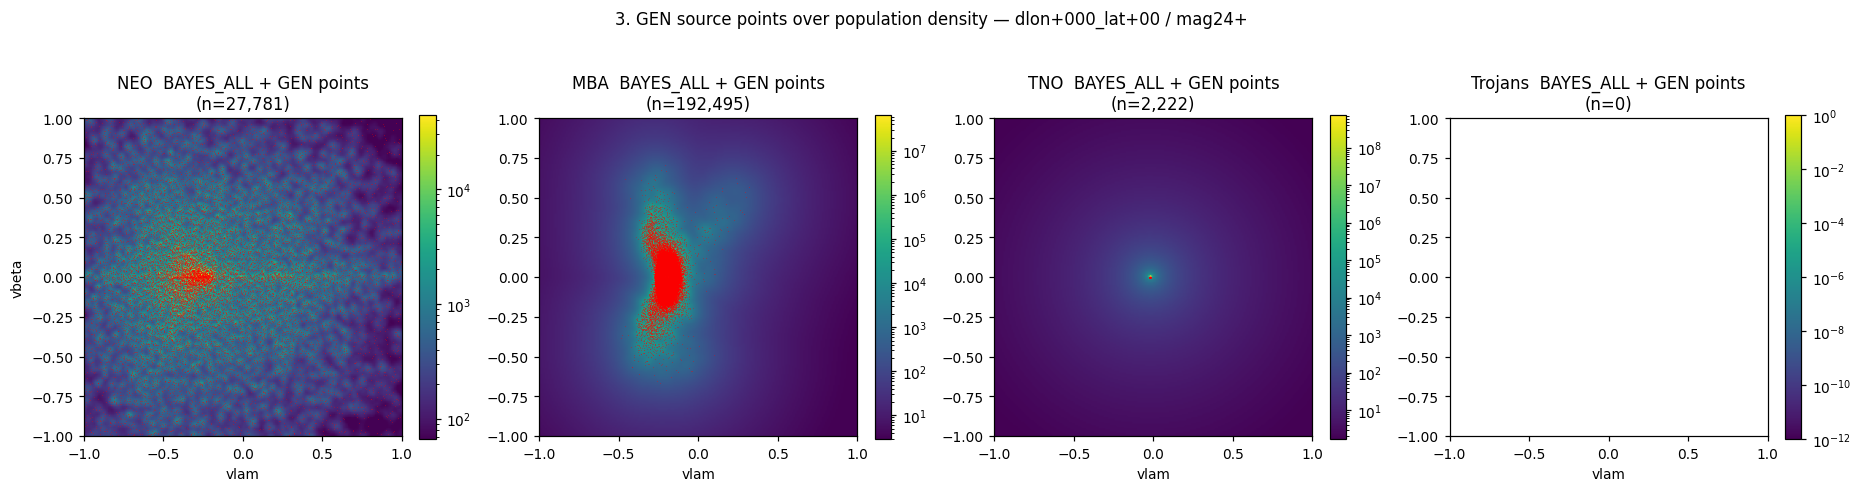

In [6]:
Z = {m: np.load(B/f"maps_{m}"/f"prob_maps_grid_{FEAT_CENTER}.npz", allow_pickle=True)
     for m in MODES}
xg, yg = Z["bayes_all"]["x_grid"], Z["bayes_all"]["y_grid"]
def dens(m,p,b=FEAT_BIN): return np.asarray(Z[m][f"density_raw__{p}__{b}"], float)
ZOOM=1.0
sl=slice(int((-ZOOM-xg[0])/0.01), int((ZOOM-xg[0])/0.01))
ext=[-ZOOM,ZOOM,-ZOOM,ZOOM]
fig,ax=plt.subplots(1,4,figsize=(17,4.3))
for i,p in enumerate(POPS):
    d=dens("bayes_all",p)[sl,sl]; pos=d[d>0]
    vmin=np.percentile(pos,1) if pos.size else 1e-12; vmax=d.max() if d.max()>0 else 1
    im=ax[i].imshow(np.where(d>0,d,np.nan),origin="lower",extent=ext,
                    norm=LogNorm(vmin=max(vmin,1e-12),vmax=max(vmax,1e-11)),cmap="viridis")
    if p in SRC and len(SRC[p]):
        s=SRC[p]; k=(np.abs(s[:,0])<ZOOM)&(np.abs(s[:,1])<ZOOM)
        ax[i].scatter(s[k,0],s[k,1],s=0.4,c="red",alpha=0.25,linewidths=0)
    ax[i].set_title(f"{p}  BAYES_ALL + GEN points\n(n={len(SRC.get(p,[])):,})")
    ax[i].set_xlabel("vlam"); ax[i].set_ylabel("vbeta") if i==0 else None
    fig.colorbar(im,ax=ax[i],fraction=0.046)
fig.suptitle(f"3. GEN source points over population density — {FEAT_CENTER} / {FEAT_BIN}",y=1.03)
fig.tight_layout(); plt.show()

## 4. Shared-scale density maps: all populations × all modes

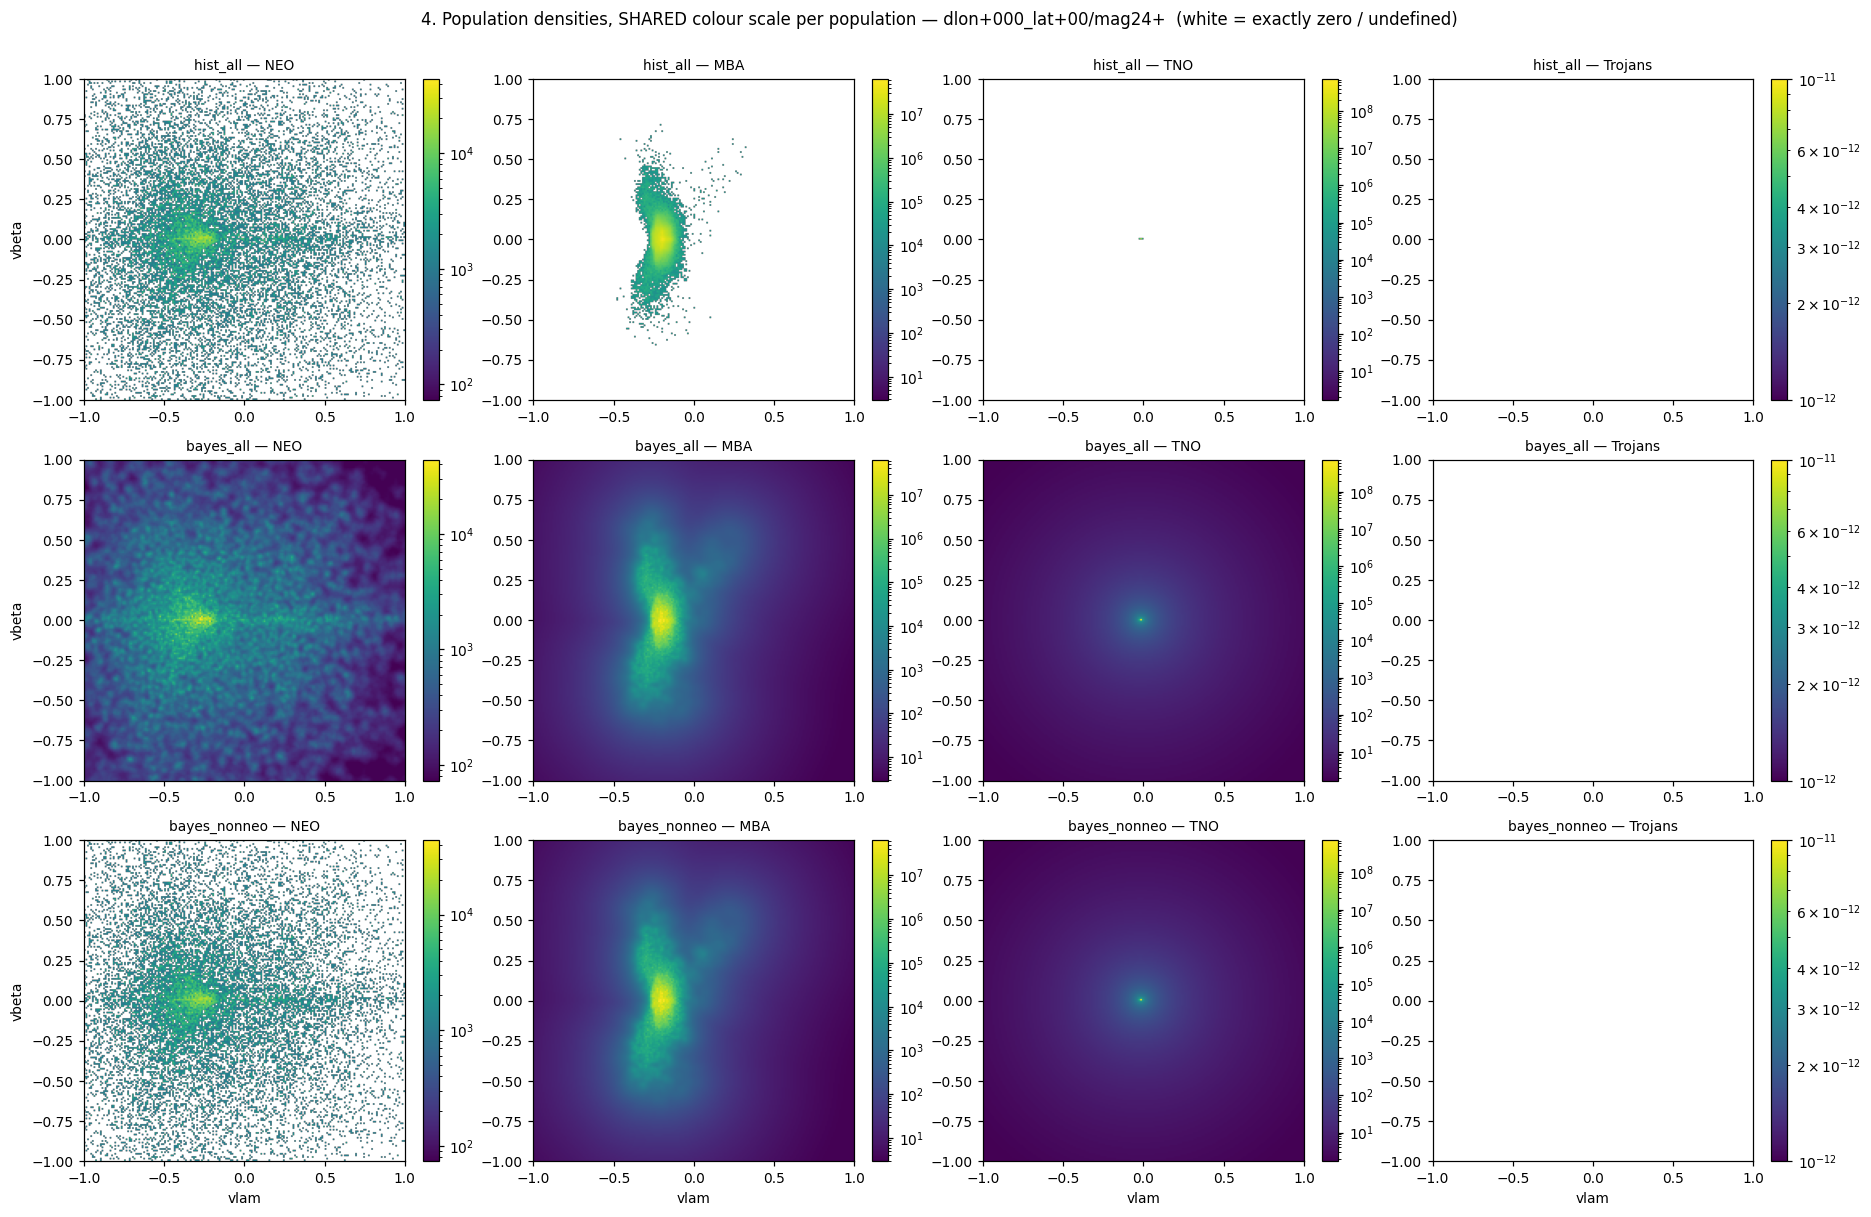

In [7]:
fig,ax=plt.subplots(len(MODES),4,figsize=(17,11))
for pi,p in enumerate(POPS):
    allv=np.concatenate([dens(m,p)[sl,sl].ravel() for m in MODES])
    pos=allv[allv>0]
    vmin=np.percentile(pos,1) if pos.size else 1e-12; vmax=pos.max() if pos.size else 1e-11
    for mi,m in enumerate(MODES):
        d=dens(m,p)[sl,sl]
        im=ax[mi,pi].imshow(np.where(d>0,d,np.nan),origin="lower",extent=ext,
                            norm=LogNorm(vmin=max(vmin,1e-12),vmax=max(vmax,1e-11)),cmap="viridis")
        ax[mi,pi].set_title(f"{m} — {p}",fontsize=9)
        if pi==0: ax[mi,pi].set_ylabel("vbeta")
        if mi==len(MODES)-1: ax[mi,pi].set_xlabel("vlam")
        fig.colorbar(im,ax=ax[mi,pi],fraction=0.046)
fig.suptitle(f"4. Population densities, SHARED colour scale per population — {FEAT_CENTER}/{FEAT_BIN}"
             "  (white = exactly zero / undefined)",y=1.0)
fig.tight_layout(); plt.show()

## 5. Shared-scale P(NEO) maps

Empty-denominator pixels are **undefined** and drawn as white — never as probability zero.

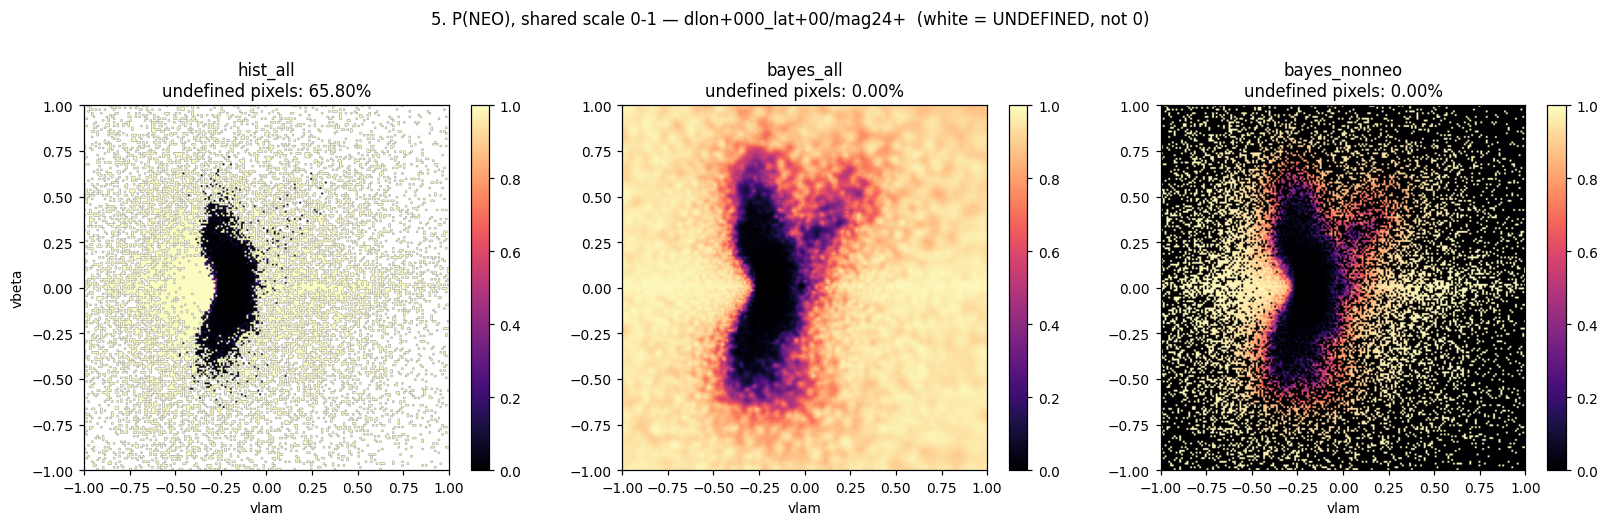

  hist_all      defined    20,819/1,002,001 (  2.08%)   undefined   981,182
  bayes_all     defined 1,002,001/1,002,001 (100.00%)   undefined         0
  bayes_nonneo  defined 1,002,001/1,002,001 (100.00%)   undefined         0


In [8]:
def post(m,b=FEAT_BIN):
    r={p:np.asarray(Z[m][f"density_raw__{p}__{b}"],float) for p in POPS}
    tot=r["NEO"]+r["MBA"]+r["TNO"]+r["Trojans"]
    ok=np.isfinite(tot)&(tot>0)
    P=np.full(tot.shape,np.nan); np.divide(r["NEO"],tot,out=P,where=ok)
    return P,ok,tot
fig,ax=plt.subplots(1,3,figsize=(15,4.4))
for i,m in enumerate(MODES):
    P,ok,_=post(m)
    im=ax[i].imshow(P[sl,sl],origin="lower",extent=ext,vmin=0,vmax=1,cmap="magma")
    und=100*(1-ok[sl,sl].mean())
    ax[i].set_title(f"{m}\nundefined pixels: {und:.2f}%")
    ax[i].set_xlabel("vlam"); ax[i].set_ylabel("vbeta") if i==0 else None
    fig.colorbar(im,ax=ax[i],fraction=0.046)
fig.suptitle(f"5. P(NEO), shared scale 0-1 — {FEAT_CENTER}/{FEAT_BIN}  (white = UNDEFINED, not 0)",y=1.04)
fig.tight_layout(); plt.show()
for m in MODES:
    P,ok,tot=post(m)
    print(f"  {m:13s} defined {int(ok.sum()):>9,}/{ok.size:,} ({100*ok.mean():6.2f}%)   "
          f"undefined {int((~ok).sum()):>9,}")

## 6. Mode-to-mode difference maps

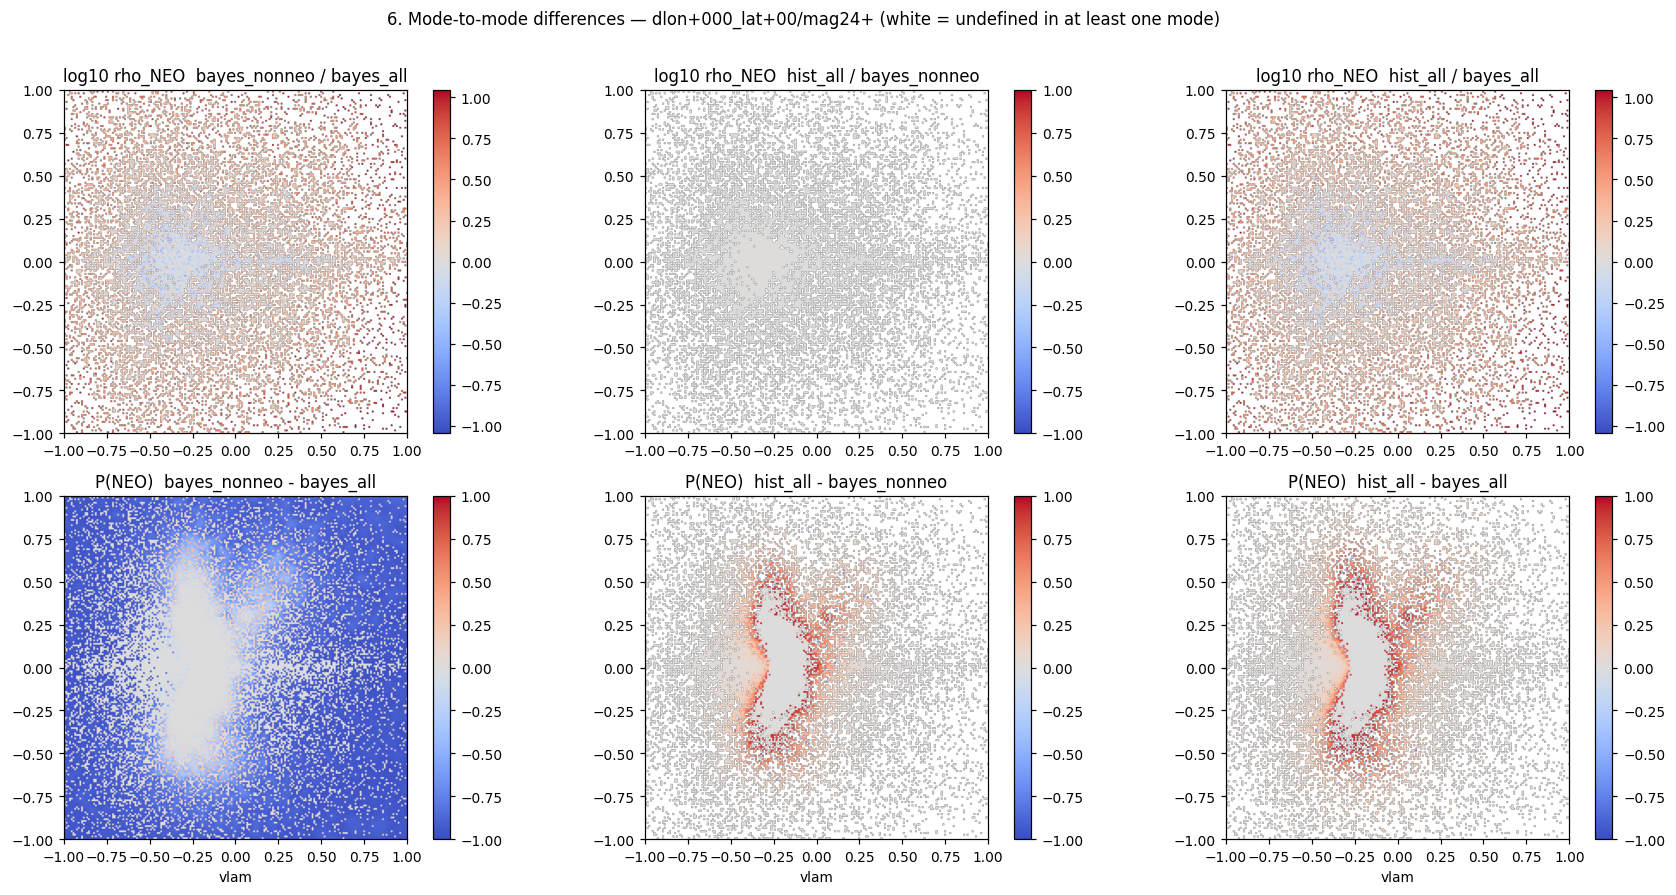

In [9]:
pairs=[("bayes_all","bayes_nonneo"),("bayes_nonneo","hist_all"),("bayes_all","hist_all")]
fig,ax=plt.subplots(2,3,figsize=(16,8))
for i,(a_,b_) in enumerate(pairs):
    da,db=dens(a_,"NEO")[sl,sl],dens(b_,"NEO")[sl,sl]
    with np.errstate(divide="ignore",invalid="ignore"):
        lr=np.log10(np.where((da>0)&(db>0),db/da,np.nan))
    # guard: TwoSlopeNorm requires vmin < vcenter < vmax strictly. If two modes share no
    # positive-density pixels the log-ratio is all-NaN and the percentile is 0 or NaN.
    v=np.nanpercentile(np.abs(lr),99) if np.isfinite(lr).any() else np.nan
    v=float(v) if (np.isfinite(v) and v>0) else 1.0
    im=ax[0,i].imshow(lr,origin="lower",extent=ext,cmap="coolwarm",
                      norm=TwoSlopeNorm(vcenter=0,vmin=-v,vmax=v))
    ax[0,i].set_title(f"log10 rho_NEO  {b_} / {a_}"); fig.colorbar(im,ax=ax[0,i],fraction=0.046)
    Pa,oa,_=post(a_); Pb,ob,_=post(b_)
    dP=np.where(oa&ob,Pb-Pa,np.nan)[sl,sl]
    im=ax[1,i].imshow(dP,origin="lower",extent=ext,cmap="coolwarm",
                      norm=TwoSlopeNorm(vcenter=0,vmin=-1,vmax=1))
    ax[1,i].set_title(f"P(NEO)  {b_} - {a_}"); fig.colorbar(im,ax=ax[1,i],fraction=0.046)
    ax[1,i].set_xlabel("vlam")
fig.suptitle(f"6. Mode-to-mode differences — {FEAT_CENTER}/{FEAT_BIN} "
             "(white = undefined in at least one mode)",y=1.01)
fig.tight_layout(); plt.show()

## 7. Pixel-level comparison tables

In [10]:
rows=[]
for m in MODES:
    P,ok,tot=post(m)
    for p in POPS:
        d=dens(m,p)
        rows.append(dict(mode=m,population=p,pixels=d.size,
            nonzero=int((d>0).sum()),zero=int((d==0).sum()),
            frac_nonzero=float((d>0).mean()),
            median_nonzero=float(np.median(d[d>0])) if (d>0).any() else np.nan,
            max=float(d.max())))
print(pd.DataFrame(rows).to_string(index=False,float_format=lambda z:f"{z:,.6g}"))
print("\nposterior definition by mode:")
pr=[]
for m in MODES:
    P,ok,tot=post(m)
    pr.append(dict(mode=m,defined=int(ok.sum()),undefined=int((~ok).sum()),
        frac_defined=float(ok.mean()),
        P_median=float(np.nanmedian(P[ok])) if ok.any() else np.nan,
        P_max=float(np.nanmax(P[ok])) if ok.any() else np.nan,
        pixels_P_eq_1=int(np.sum(P[ok]==1.0)), pixels_P_eq_0=int(np.sum(P[ok]==0.0))))
print(pd.DataFrame(pr).to_string(index=False,float_format=lambda z:f"{z:,.6g}"))

        mode population  pixels  nonzero    zero  frac_nonzero  median_nonzero         max
    hist_all        NEO 1002001    20165  981836     0.0201247        1,143.29    22,865.8
    hist_all        MBA 1002001     2160  999841    0.00215569        49,988.6 4.16905e+07
    hist_all        TNO 1002001        3 1001998   2.99401e-06     1.30831e+06 3.55424e+07
    hist_all    Trojans 1002001        0 1002001             0             NaN           0
   bayes_all        NEO 1002001  1002001       0             1        0.721626    43,893.3
   bayes_all        MBA 1002001  1002001       0             1        0.239907 6.36923e+07
   bayes_all        TNO 1002001  1002001       0             1        0.182959 7.33125e+08
   bayes_all    Trojans 1002001        0 1002001             0             NaN           0
bayes_nonneo        NEO 1002001    20165  981836     0.0201247        1,143.29    22,865.8
bayes_nonneo        MBA 1002001  1002001       0             1        0.239907 6.36923e+07

## 8. Integrated density vs known weighted source count

In [11]:
PIX=0.01*0.01
rows=[]
for m in MODES:
    A=acc[m]; A=A[(A.center==FEAT_CENTER)]
    for p in POPS:
        s=A[A.population==p]
        if not len(s): continue
        for _,r in s.iterrows():
            d=np.asarray(Z[m][f"density_raw__{p}__{r.magnitude_bin}"],float)
            rows.append(dict(mode=m,population=p,bin=r.magnitude_bin,
                integral=float(np.nansum(d)*PIX),
                expected_weighted_source_count=float(r.expected_in_domain_physical_count),
                ratio=float(np.nansum(d)*PIX)/r.expected_in_domain_physical_count
                      if r.expected_in_domain_physical_count>0 else np.nan))
T=pd.DataFrame(rows)
print(f"featured center {FEAT_CENTER}:")
print(T.pivot_table(index=["population","bin"],columns="mode",values="ratio")
      .to_string(float_format=lambda z:f"{z:,.4f}"))

featured center dlon+000_lat+00:
mode               bayes_all  bayes_nonneo  hist_all
population bin                                      
MBA        14_16      1.4584        1.4584    1.0000
           16_18      1.1770        1.1770    1.0000
           18_20      1.1339        1.1339    1.0000
           mag20      1.1290        1.1290    1.0000
           mag21      1.1250        1.1250    1.0000
           mag22      1.1189        1.1189    1.0000
           mag23      1.0944        1.0944    1.0000
           mag24+     1.1619        1.1619    1.0000
NEO        14_16      1.1060        1.0000    1.0000
           16_18      1.5980        1.0000    1.0000
           18_20      1.2307        1.0000    1.0000
           mag20      1.1777        1.0000    1.0000
           mag21      1.1613        1.0000    1.0000
           mag22      1.1458        1.0000    1.0000
           mag23      1.1387        1.0000    1.0000
           mag24+     1.1393        1.0000    1.0000
TNO        18

## 9. Summaries over every map and magnitude bin (all 667 centers)

In [12]:
allr=[]
for m in MODES:
    A=acc[m].copy(); A["mode"]=m; allr.append(A)
AL=pd.concat(allr,ignore_index=True)
print("integral ratio (after physical normalization / expected in-domain count):")
print(AL.groupby(["mode","population","backend"]).ratio_after_norm_to_expected
      .agg(["count","median","min","max"]).to_string(float_format=lambda z:f"{z:,.4f}"))
print("\nby magnitude bin (median ratio):")
print(AL.pivot_table(index="magnitude_bin",columns=["mode","population"],
      values="ratio_after_norm_to_expected",aggfunc="median")
      .reindex(BINS).to_string(float_format=lambda z:f"{z:,.3f}"))

integral ratio (after physical normalization / expected in-domain count):
                                 count  median    min     max
mode         population backend                              
bayes_all    MBA        bayes     5298  1.1533 1.0687  5.3292
             NEO        bayes     4916  1.1741 0.7389  2.4151
             TNO        bayes     3509  4.7795 0.7295 34.7604
             Trojans    bayes     2503  1.5061 1.0599  7.4352
bayes_nonneo MBA        bayes     5298  1.1533 1.0687  5.3292
             NEO        hist      4916  1.0000 1.0000  1.0000
             TNO        bayes     3509  4.7795 0.7295 34.7604
             Trojans    bayes     2503  1.5061 1.0599  7.4352
hist_all     MBA        hist      5298  1.0000 1.0000  1.0000
             NEO        hist      4916  1.0000 1.0000  1.0000
             TNO        hist      3509  1.0000 1.0000  1.0000
             Trojans    hist      2503  1.0000 1.0000  1.0000

by magnitude bin (median ratio):
mode          bayes_all 

## 10. Empty histogram pixels are undefined, not zero probability

Counted explicitly across a sample of centers.

In [13]:
samp=sorted([Path(f).name.replace("prob_maps_grid_","").replace(".npz","")
              for f in glob.glob(str(B/"maps_hist_all"/"prob_maps_grid_*.npz"))])[::40]
rows=[]
for cen in samp:
    zz={m:np.load(B/f"maps_{m}"/f"prob_maps_grid_{cen}.npz",allow_pickle=True) for m in MODES}
    for m in MODES:
        for b in BINS:
            k=f"density_raw__NEO__{b}"
            if k not in zz[m].files: continue
            r={p:np.asarray(zz[m][f"density_raw__{p}__{b}"],float) for p in POPS}
            tot=sum(r.values()); ok=np.isfinite(tot)&(tot>0)
            rows.append(dict(center=cen,mode=m,bin=b,undefined=int((~ok).sum()),
                             defined=int(ok.sum()),frac_undefined=float((~ok).mean())))
    for m in MODES: zz[m].close()
U=pd.DataFrame(rows)
print(f"sampled centers: {U.center.nunique()}")
print(U.groupby("mode").frac_undefined.describe()[["count","mean","50%","max"]]
      .to_string(float_format=lambda z:f"{z:,.4f}"))
print("\nIn every mode these pixels carry NaN with a reason code in the archive; they are never")
print("written or plotted as P(NEO)=0.")
for m in MODES:
    z0=np.load(B/f"maps_{m}"/f"prob_maps_grid_{FEAT_CENTER}.npz",allow_pickle=True)
    rk=[k for k in z0.files if k.startswith("posterior_reason__")]
    vk=[k for k in z0.files if k.startswith("posterior_valid__")]
    print(f"  {m:13s} reason arrays {len(rk)}   valid-mask arrays {len(vk)}")
    z0.close()

sampled centers: 17
                count   mean    50%    max
mode                                      
bayes_all    136.0000 0.0000 0.0000 0.0000
bayes_nonneo 136.0000 0.0000 0.0000 0.0000
hist_all     136.0000 0.9965 0.9981 1.0000

In every mode these pixels carry NaN with a reason code in the archive; they are never
written or plotted as P(NEO)=0.
  hist_all      reason arrays 8   valid-mask arrays 8


  bayes_all     reason arrays 8   valid-mask arrays 8
  bayes_nonneo  reason arrays 8   valid-mask arrays 8


## 11. Detailed default view — GEN-densest NEO cell

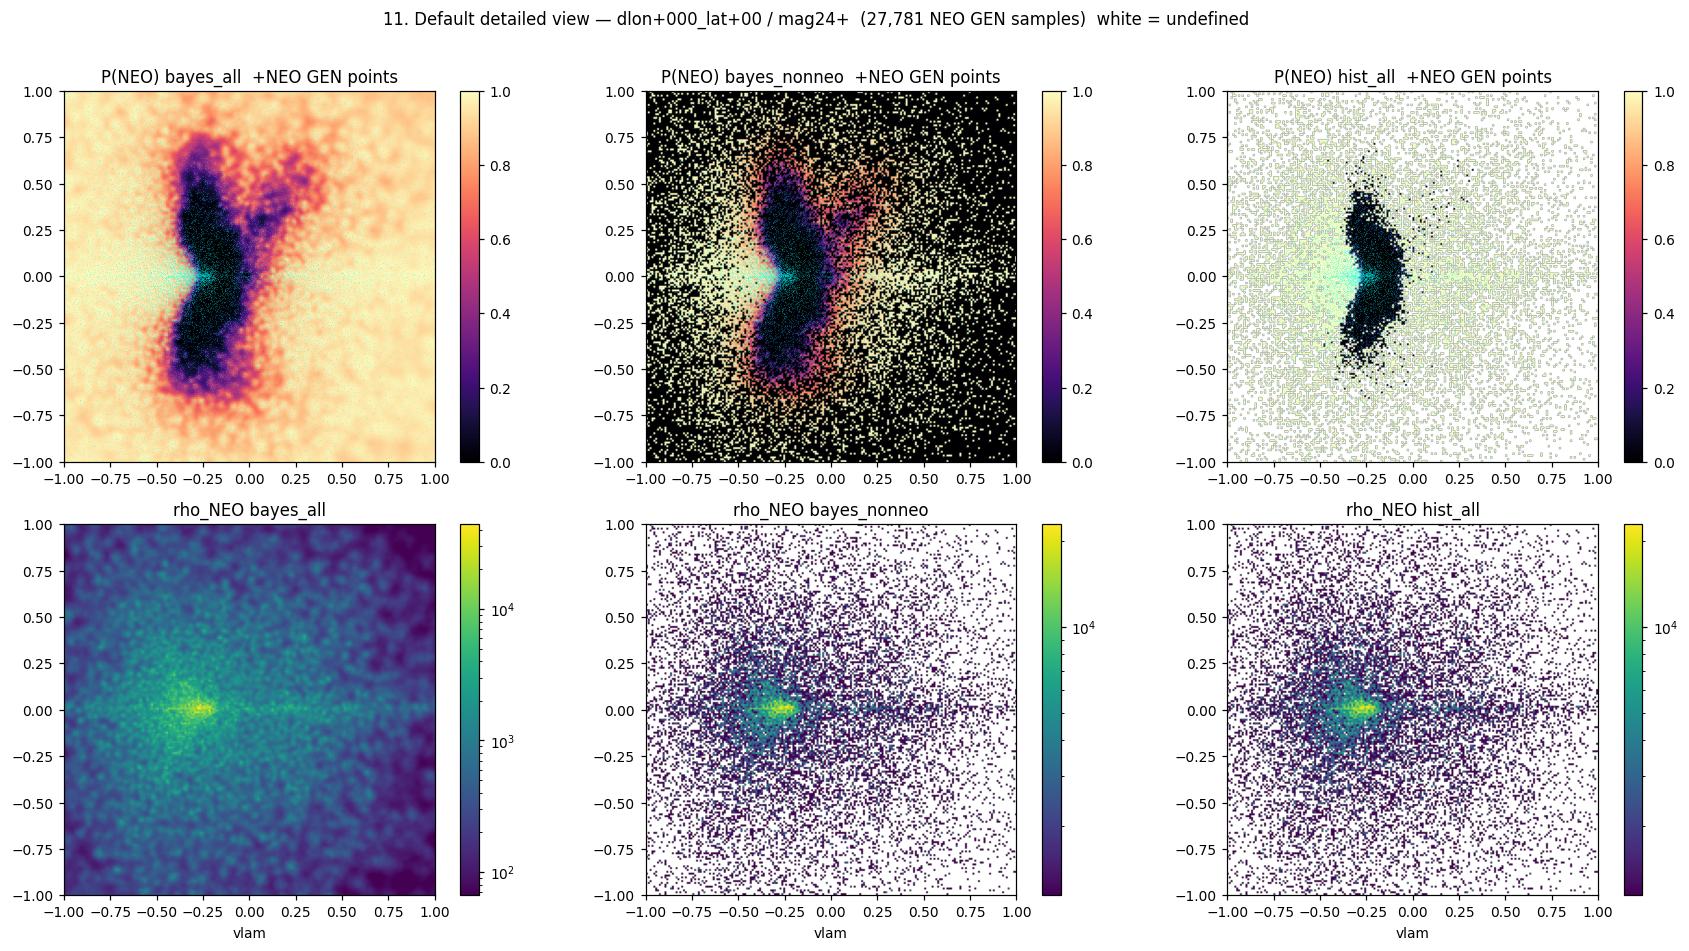

1-D slice through vbeta=0:
        vlam  rho_NEO_hist_all  P_hist_all  rho_NEO_bayes_all  P_bayes_all  rho_NEO_bayes_nonneo  P_bayes_nonneo
          -1                 0         NaN           1,150.38     0.991524                     0               0
        -0.8                 0         NaN            1,052.5      0.98339                     0               0
        -0.6          1,143.29           1           2,027.89     0.979221              1,143.29        0.963727
        -0.4          8,003.04           1            8,306.5     0.970912              8,003.04        0.969843
        -0.2          9,146.33  0.00022272           12,127.4  0.000355249              9,146.33     0.000267949
-1.06581e-13          1,143.29           1           3,010.41     0.147951              1,143.29       0.0618656
         0.2          2,286.58           1           2,653.73     0.935574              2,286.58        0.925995
         0.4          1,143.29           1           1,205.56     0.9

In [14]:
P_ba,ok_ba,_=post("bayes_all"); P_ha,ok_ha,_=post("hist_all"); P_bn,ok_bn,_=post("bayes_nonneo")
fig,ax=plt.subplots(2,3,figsize=(16,8.5))
for i,(m,P,ok) in enumerate([("bayes_all",P_ba,ok_ba),("bayes_nonneo",P_bn,ok_bn),
                             ("hist_all",P_ha,ok_ha)]):
    im=ax[0,i].imshow(P[sl,sl],origin="lower",extent=ext,vmin=0,vmax=1,cmap="magma")
    s=SRC.get("NEO",np.zeros((0,2)))
    k=(np.abs(s[:,0])<ZOOM)&(np.abs(s[:,1])<ZOOM) if len(s) else np.zeros(0,bool)
    if len(s): ax[0,i].scatter(s[k,0],s[k,1],s=0.3,c="cyan",alpha=0.18,linewidths=0)
    ax[0,i].set_title(f"P(NEO) {m}  +NEO GEN points")
    fig.colorbar(im,ax=ax[0,i],fraction=0.046)
    d=dens(m,"NEO")[sl,sl]
    im=ax[1,i].imshow(np.where(d>0,d,np.nan),origin="lower",extent=ext,
                      norm=LogNorm(vmin=max(np.percentile(d[d>0],1),1e-12) if (d>0).any() else 1e-12,
                                   vmax=max(d.max(),1e-11)),cmap="viridis")
    ax[1,i].set_title(f"rho_NEO {m}"); ax[1,i].set_xlabel("vlam")
    fig.colorbar(im,ax=ax[1,i],fraction=0.046)
fig.suptitle(f"11. Default detailed view — {FEAT_CENTER} / {FEAT_BIN}  "
             f"({len(SRC.get('NEO',[])):,} NEO GEN samples)  white = undefined",y=1.01)
fig.tight_layout(); plt.show()
print("1-D slice through vbeta=0:")
row=int((0-yg[0])/0.01)
sldf=pd.DataFrame({"vlam":xg[sl]})
for m in MODES:
    sldf[f"rho_NEO_{m}"]=dens(m,"NEO")[row,sl]
    Pm,okm,_=post(m); sldf[f"P_{m}"]=np.where(okm[row,sl],Pm[row,sl],np.nan)
print(sldf.iloc[::20].head(20).to_string(index=False,float_format=lambda z:f"{z:,.6g}"))